# Iris Flower Classification

This notebook demonstrates the classification of Iris flowers into three species: Setosa, Versicolor, and Virginica using Machine Learning.

## 1. Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# Set visual style
sns.set(style="whitegrid")

## 2. Load the Dataset

In [9]:
# Loading the dataset from the provided path
df = pd.read_csv('../TASK-1 DATASET/Iris.csv')

# Display the first few rows
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Exploratory Data Analysis (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000    

C:\Users\PRACHIGARG\AppData\Local\Temp\ipykernel_57584\1324413631.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=df, palette='viridis')


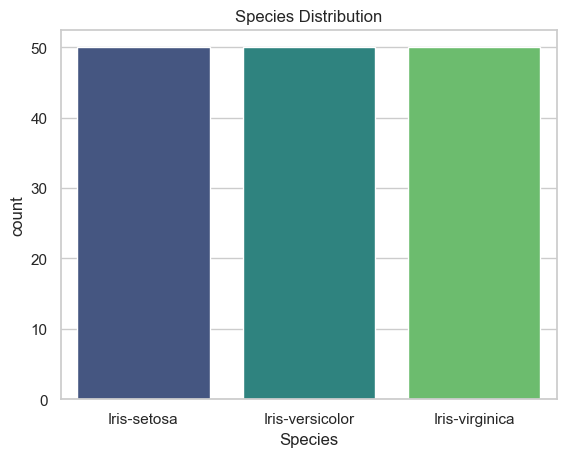

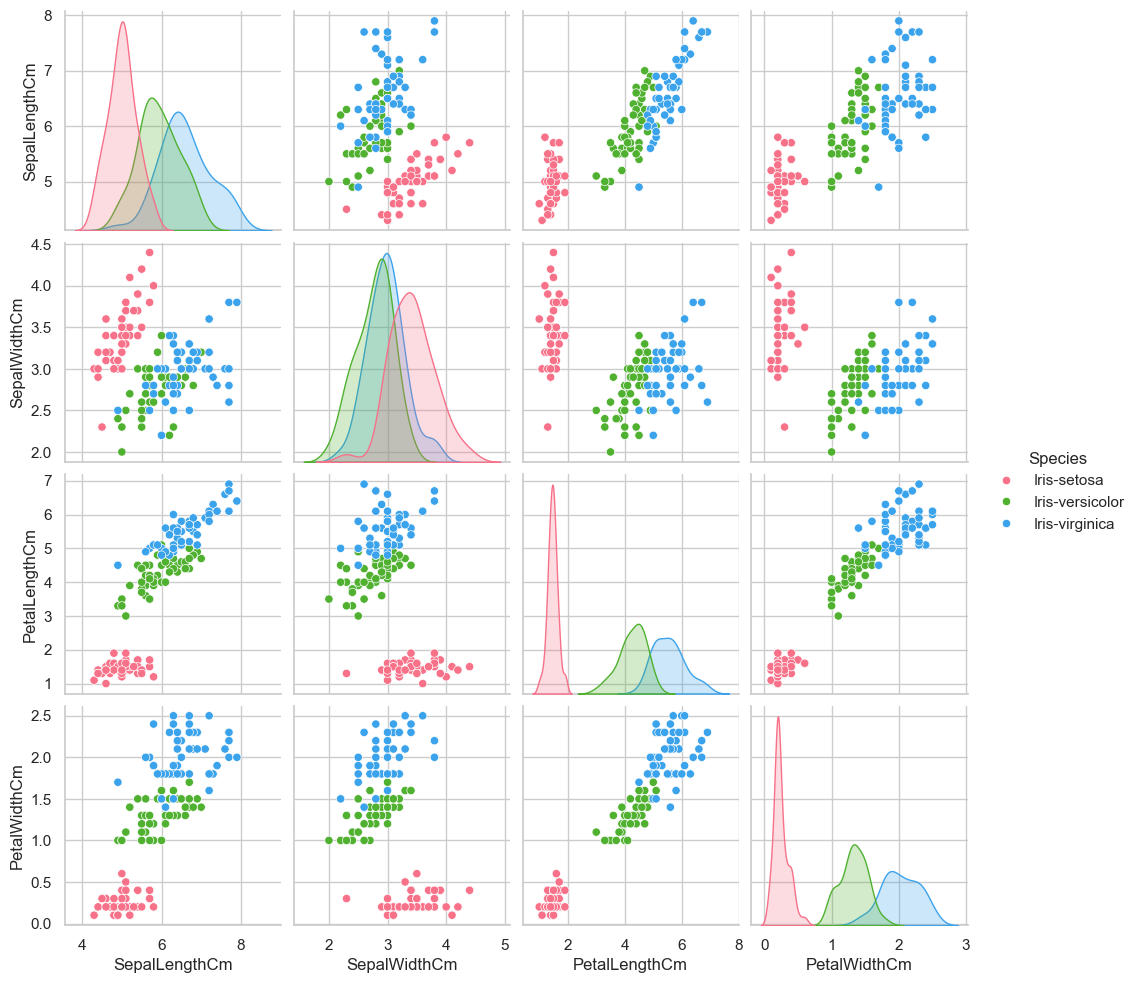

In [10]:
# Check for missing values and data types
print(df.info())

# Summary statistics
print(df.describe())

# Dropping 'Id' column as it is not needed for classification
if 'Id' in df.columns:
    df.drop('Id', axis=1, inplace=True)

# Visualizing the distribution of species
sns.countplot(x='Species', data=df, palette='viridis')
plt.title('Species Distribution')
plt.show()

# Pairplot to see relationships between features
sns.pairplot(df, hue='Species', palette='husl')
plt.show()

## 4. Data Preprocessing

In [11]:
# Encoding the target variable (Species)
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

# Splitting the data into features and target
X = df.drop('Species', axis=1)
y = df['Species']

# Splitting into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Model Building - Random Forest Classifier

In [12]:
# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

## 6. Evaluation

Accuracy: 100.00%


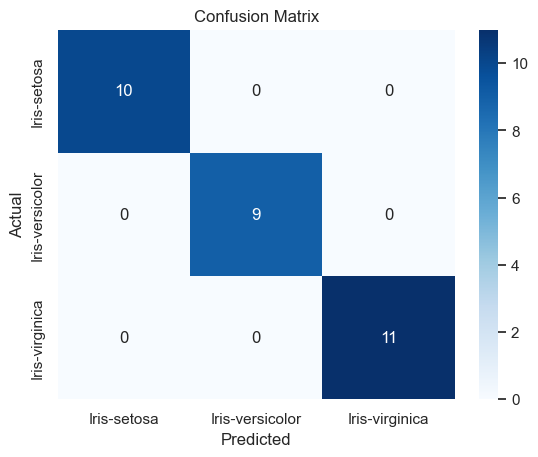


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [13]:
# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

## 7. Testing with Sample Data

In [14]:
# Predicting a new sample
sample = np.array([[5.1, 3.5, 1.4, 0.2]]) # Example: Setosa features
prediction = model.predict(sample)
predicted_species = le.inverse_transform(prediction)
print(f"Predicted Species for {sample}: {predicted_species[0]}")

Predicted Species for [[5.1 3.5 1.4 0.2]]: Iris-setosa


c:\Users\PRACHIGARG\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
